# Spatial Context AI Model

Does adding spatial context improve prediction of immune-high regions beyond gene expression alone?

## 1. Load Data

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

adata = sc.read_h5ad("../data/processed/breast_cancer_spatial_analysis.h5ad")

## 2. Recreate scores and target

In [2]:
immune_genes = ["PTPRC", "CD3D", "CD74", "HLA-DRA", "HLA-DPB1"]
epithelial_genes = ["EPCAM", "KRT8", "KRT18"]
stromal_genes = ["COL1A1", "COL1A2", "MGP"]

immune_genes = [g for g in immune_genes if g in adata.var_names]
epithelial_genes = [g for g in epithelial_genes if g in adata.var_names]
stromal_genes = [g for g in stromal_genes if g in adata.var_names]

sc.tl.score_genes(adata, immune_genes, score_name="immune_score")
sc.tl.score_genes(adata, epithelial_genes, score_name="epithelial_score")
sc.tl.score_genes(adata, stromal_genes, score_name="stromal_score")

adata.obs["immune_binary"] = (adata.obs["immune_score"] > 1).astype(int)
adata.obs["immune_binary"].value_counts()

immune_binary
0    3383
1     415
Name: count, dtype: int64

## 3. Build spatial graph

In [3]:
sq.gr.spatial_neighbors(adata)

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


## 4. Create neighbor-context features

In [4]:
W = adata.obsp["spatial_connectivities"].copy()

def neighbor_average(values):
    neighbor_sum = W @ values
    neighbor_count = np.asarray(W.sum(axis=1)).flatten()
    return neighbor_sum / np.maximum(neighbor_count, 1)

adata.obs["neighbor_immune_score"] = neighbor_average(
    adata.obs["immune_score"].values
)

adata.obs["neighbor_epithelial_score"] = neighbor_average(
    adata.obs["epithelial_score"].values
)

adata.obs["neighbor_stromal_score"] = neighbor_average(
    adata.obs["stromal_score"].values
)

## 5. Add spatial coordinates

In [5]:
coords = pd.DataFrame(
    adata.obsm["spatial"],
    columns=["spatial_x", "spatial_y"],
    index=adata.obs_names
)

adata.obs[["spatial_x", "spatial_y"]] = coords

## 6. Gene-expression-only model

In [6]:
if "highly_variable" in adata.var.columns:
    adata_ml = adata[:, adata.var["highly_variable"]].copy()
else:
    adata_ml = adata.copy()

X_gene = adata_ml.X
if not isinstance(X_gene, np.ndarray):
    X_gene = X_gene.toarray()

y = adata.obs["immune_binary"].values

X_train_g, X_test_g, y_train, y_test = train_test_split(
    X_gene,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf_gene = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_gene.fit(X_train_g, y_train)

prob_gene = rf_gene.predict_proba(X_test_g)[:, 1]
pred_gene = rf_gene.predict(X_test_g)

print(classification_report(y_test, pred_gene))
auc_gene = roc_auc_score(y_test, prob_gene)
print("Gene-only ROC AUC:", auc_gene)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       846
           1       0.61      0.74      0.67       104

    accuracy                           0.92       950
   macro avg       0.79      0.84      0.81       950
weighted avg       0.93      0.92      0.92       950

Gene-only ROC AUC: 0.9519458083287872


## 7. Spatial-context model

In [7]:
context_features = adata.obs[
    [
        "neighbor_immune_score",
        "neighbor_epithelial_score",
        "neighbor_stromal_score",
        "spatial_x",
        "spatial_y"
    ]
].values

X_context = np.hstack([X_gene, context_features])

In [8]:
indices = np.arange(adata.n_obs)

train_idx, test_idx, y_train, y_test = train_test_split(
    indices,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train_c = X_context[train_idx]
X_test_c = X_context[test_idx]

rf_context = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_context.fit(X_train_c, y_train)

prob_context = rf_context.predict_proba(X_test_c)[:, 1]
pred_context = rf_context.predict(X_test_c)

print(classification_report(y_test, pred_context))
auc_context = roc_auc_score(y_test, prob_context)
print("Spatial-context ROC AUC:", auc_context)

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       846
           1       0.62      0.74      0.68       104

    accuracy                           0.92       950
   macro avg       0.79      0.84      0.82       950
weighted avg       0.93      0.92      0.93       950

Spatial-context ROC AUC: 0.9535938352427713


## 8. Compare models

In [9]:
comparison = pd.DataFrame({
    "Model": ["Gene expression only", "Gene expression + spatial context"],
    "ROC AUC": [auc_gene, auc_context]
})

comparison

,Model,ROC AUC
0,Gene expression only,0.951946
1,Gene expression + spatial context,0.953594


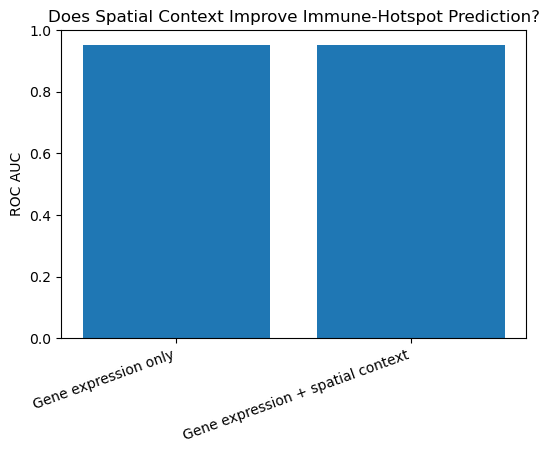

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["ROC AUC"])
plt.ylabel("ROC AUC")
plt.title("Does Spatial Context Improve Immune-Hotspot Prediction?")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.show()

## 9. ROC curves together

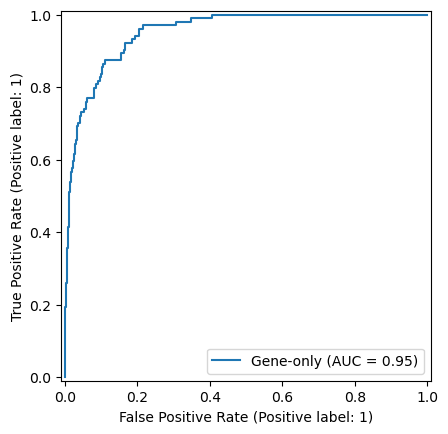

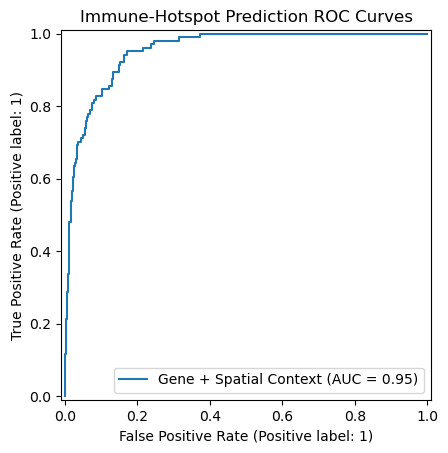

In [11]:
RocCurveDisplay.from_predictions(
    y_test,
    prob_gene,
    name="Gene-only"
)

RocCurveDisplay.from_predictions(
    y_test,
    prob_context,
    name="Gene + Spatial Context"
)

plt.title("Immune-Hotspot Prediction ROC Curves")
plt.show()

## Interpretation

The immune signal is already encoded in the transcriptome itself.

Spatial context provided minimal additional predictive value beyond local gene expression for identifying immune-high regions.

1. Can gene expression predict immune hotspots? Yes (AUC appr 0.95)

2. Does spatial context improve prediction? Not substantially in this sample. (AUC increase 0.9519 -> 0.9536)

3. What genes drive prediction?
PTPRC
HLA-DPB1
HLA-DPA1
HLA-DQA1
HLA-DQB1
TRBC2
C1QA
C1QB
CCL5

### Biological Findings
- Immune and epithelial programs are inversely related
- Immune-rich regions are stromal-enriched
- B-cell/plasma-cell genes show strong spatial organization
- Multiple immune niches exist within the tissue

### AI Findings
- Immune hotspots are highly predictable from transcriptomic profiles
- Random Forest achieves ROC AUC ≈ 0.95
- Key predictive genes are immune-related
- Spatial context adds little predictive value beyond local expression